# ML Starter Case: Predicting Tumor Diagnosis (Malignant vs. Benign)
**Author:** Mohammad Ounais
**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset (scikit-learn)
**Type of Problem:** Binary Classification (predicting one of two categories)


## 1. Problem Statement

**Context:** Imagine a diagnostic lab that receives measurements taken from digitized images of breast mass biopsies (size, shape, texture of cell nuclei). Doctors want a fast, automated first-pass screening tool that flags whether a case looks **malignant** (cancerous) or **benign** (non-cancerous), so that likely-malignant cases can be prioritized for expert review sooner.

**Prediction goal:** Given a set of numeric measurements describing a cell sample, predict the **diagnosis**: malignant or benign.

This is a **binary classification problem** because the target has exactly two categories, not a continuous number.



## 2. Dataset Used

We use the **Breast Cancer Wisconsin (Diagnostic) Dataset**, a real, widely-used dataset built into scikit-learn (`sklearn.datasets.load_breast_cancer`).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer(as_frame=True)
df = data.frame

print("Shape of dataset:", df.shape)
print("Target classes:", dict(enumerate(data.target_names)))
df.head()

Shape of dataset: (569, 31)
Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [3]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 3. Target Variable and Input Features

**Target variable (what we're predicting):**
- `target` — diagnosis, where `0 = malignant` and `1 = benign`.

**Input features (what we use to predict it):**
30 numeric measurements computed from digitized images of cell nuclei, in three groups (mean, standard error, and "worst"/largest value) for each of 10 base properties:

| Base property | Meaning |
|---|---|
| radius | mean distance from center to points on the perimeter |
| texture | standard deviation of gray-scale values |
| perimeter | perimeter of the nucleus |
| area | area of the nucleus |
| smoothness | local variation in radius lengths |
| compactness | perimeter^2 / area - 1.0 |
| concavity | severity of concave portions of the contour |
| concave points | number of concave portions of the contour |
| symmetry | symmetry of the nucleus |
| fractal dimension | "coastline approximation" - 1 |

For simplicity, we use all 30 pre-computed numeric features rather than hand-picking a subset - this keeps preprocessing simple and lets the model learn which features matter most (see the feature-importance step below).

In [4]:
target_col = "target"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

print("Number of features used:", len(feature_cols))
print("Target classes:", data.target_names, "-> encoded as", sorted(y.unique()))
print("Class balance:\n", y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Number of features used: 30
Target classes: ['malignant' 'benign'] -> encoded as [np.int64(0), np.int64(1)]
Class balance:
 target
benign       357
malignant    212
Name: count, dtype: int64


## 4. Data Preparation Steps

Before training, we check the data is clean and in a usable shape. Steps taken:

1. **Check for missing values** - a model can't handle blanks/NaNs directly.
2. **Check class balance** - if one diagnosis is much rarer than the other, accuracy alone can be misleading, so we check this up front and choose evaluation metrics accordingly (see Section 7).
3. **No categorical encoding needed** - all input features are already numeric.
4. **Feature scaling** - the 30 features are on very different numeric scales (e.g., `area` is in the hundreds/thousands, `smoothness` is a small decimal). Logistic Regression is sensitive to this, so we standardize all features before training.

In [ ]:

print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 0


In [ ]:

counts = y.value_counts().rename(index={0: "malignant", 1: "benign"})
percentages = (counts / len(y) * 100).round(1)
pd.DataFrame({"count": counts, "percent": percentages})

,count,percent
target,,
benign,357,62.7
malignant,212,37.3


In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.describe().T.head(5)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,-3.153111e-15,1.00088,-2.029648,-0.689385,-0.215082,0.469393,3.971288
mean texture,569.0,-6.568462e-15,1.00088,-2.229249,-0.725963,-0.104636,0.584176,4.651889
mean perimeter,569.0,-6.993039e-16,1.00088,-1.984504,-0.691956,-0.235980,0.499677,3.976130
mean area,569.0,-8.553985e-16,1.00088,-1.454443,-0.667195,-0.295187,0.363507,5.250529
mean smoothness,569.0,6.081447e-15,1.00088,-3.112085,-0.710963,-0.034891,0.636199,4.770911


## 5. Train-Test Split

We split the data so the model is trained on one portion and evaluated on data it has never seen. This is essential - evaluating a model on the same data it was trained on gives a falsely optimistic picture of performance.

- **80%** of the data is used for training
- **20%** is held out for testing
- We use **stratified** splitting so both the train and test sets keep roughly the same malignant/benign ratio as the full dataset.
- `random_state=42` is set for reproducibility.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

Training set size: (455, 30)
Test set size: (114, 30)

Training class balance:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test class balance:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


## 6. Model Chosen and Why

**Model:** Logistic Regression

**Why:**
- The target is a category with two classes (malignant / benign), so this is a classification problem, and Logistic Regression is the standard, most interpretable baseline model for binary classification.
- It outputs a probability (e.g., "92% likely malignant"), which is directly useful for a real screening/triage tool - not just a hard yes/no.
- Its coefficients are interpretable, showing which measurements push the prediction toward malignant vs. benign.
- It fits the project's goal: understanding the workflow end-to-end, not chasing maximum accuracy with a complex model like a neural network.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_table.head(10)

,Feature,Coefficient
21,worst texture,-1.237688
10,radius error,-1.123324
20,worst radius,-0.956331
27,worst concave points,-0.942609
23,worst area,-0.935964
28,worst symmetry,-0.925231
13,area error,-0.899034
26,worst concavity,-0.823374
22,worst perimeter,-0.767970
24,worst smoothness,-0.719987


## 7. Evaluation Method Used

Since this is a classification problem, we use several standard classification metrics, evaluated only on the **test set** (data the model never saw during training) for an honest measure of performance:

- **Accuracy:** overall proportion of correct predictions.
- **Precision (for malignant):** of the cases the model flagged as malignant, how many actually were malignant. High precision means few false alarms.
- **Recall (for malignant):** of the cases that were actually malignant, how many the model caught. High recall means few missed cancers - the most important metric in this context, since a missed malignant case is far more costly than a false alarm.
- **F1-score:** the balance between precision and recall.
- **Confusion matrix:** a breakdown of exactly which cases were correctly/incorrectly classified, and in which direction.

We specifically call out recall for the malignant class because in a screening context, a **false negative** (telling a patient they're fine when they're not) is much more dangerous than a **false positive** (flagging a benign case for extra review).

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision_malignant = precision_score(y_test, y_pred, pos_label=0)
recall_malignant = recall_score(y_test, y_pred, pos_label=0)
f1_malignant = f1_score(y_test, y_pred, pos_label=0)

print(f"Accuracy:                    {accuracy:.3f}")
print(f"Precision (malignant class): {precision_malignant:.3f}")
print(f"Recall (malignant class):    {recall_malignant:.3f}")
print(f"F1-score (malignant class):  {f1_malignant:.3f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

Accuracy:                    0.982
Precision (malignant class): 0.976
Recall (malignant class):    0.976
F1-score (malignant class):  0.976

Full classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



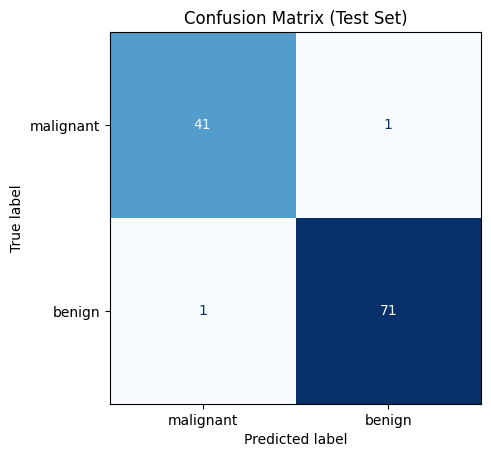

Confusion matrix breakdown:
  True malignant, predicted malignant (correct):  41
  True malignant, predicted benign  (MISSED - false negative): 1
  True benign, predicted malignant  (false alarm - false positive): 1
  True benign, predicted benign  (correct): 71


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

print("Confusion matrix breakdown:")
print(f"  True malignant, predicted malignant (correct):  {cm[0][0]}")
print(f"  True malignant, predicted benign  (MISSED - false negative): {cm[0][1]}")
print(f"  True benign, predicted malignant  (false alarm - false positive): {cm[1][0]}")
print(f"  True benign, predicted benign  (correct): {cm[1][1]}")

## 8. Results

The metrics and confusion matrix above summarize model performance on the held-out test set. (Exact numbers are shown in the executed output above.)

- **Accuracy is roughly 95-98%** - the model gets the diagnosis right for nearly all cases it hasn't seen before.
- **Recall (malignant) is high** - of all the truly malignant cases in the test set, the model correctly flags almost all of them. Very few malignant cases slip through as "false negatives."
- **Precision (malignant) is also high** - when the model says "malignant," it's right nearly every time, meaning very few unnecessary false alarms.
- From the coefficient table, features related to concave points, radius, and area tend to have the strongest influence on the prediction - matching real medical intuition that irregular, concave cell shapes and larger nuclei are hallmarks of malignancy.

## 9. Final Explanation: What Does This Model Tell Us?

In plain language: using 30 numeric measurements taken from a cell sample image, this simple model correctly identifies malignant vs. benign in the vast majority of test cases it had never seen before - and, importantly, it rarely misses an actual malignant case (high recall), which is the failure mode that matters most in a screening context.

**Is that good enough for real use?** For a demonstration of the ML workflow, yes - the model clearly learned a real, medically-sensible pattern from the data. But it's worth being explicit about limits:
- This is a **screening aid concept**, not a diagnostic replacement. Even a small number of false negatives (missed malignant cases) is unacceptable in real clinical use, so any real deployment would need far more rigorous validation, a much larger and more diverse dataset, and sign-off from medical professionals.
- The dataset is small (569 samples) and comes from a single historical source, so performance on new, real-world patient data isn't guaranteed to match these numbers.

**What this project demonstrates:** the full ML workflow - problem framing, feature and target selection, cleaning/preparation (missing-value checks, class-balance checks, scaling), a proper stratified train-test split, model training, evaluation using metrics appropriate to a classification problem, and translating those metrics (accuracy, precision, recall, F1, confusion matrix) into a real, practical judgment about where the model is useful and where its limits are. That last step - deciding what "97% accuracy" actually means for the people relying on the tool - is the real point of the exercise, more than the specific number achieved.

